# Phase 11 — Fair lending review

In the United States, ECOA and Regulation B prohibit lending discrimination on
race, colour, religion, national origin, sex, marital status, age, and receipt
of public assistance. A lender cannot deploy a scorecard without testing for
**disparate impact**: a model that uses no prohibited attribute can still
produce outcomes that disadvantage a protected group, through proxies.

This is a legal requirement rather than an optional extra, and it is almost
always missing from portfolio projects. This notebook runs the screening a
real second-line review would start with, and is explicit about where the
available data stops that analysis short.

**Note the shape of the problem.** This dataset contains no protected
attribute at all — by design, since lenders are generally barred from
collecting race for consumer credit (mortgage lending under HMDA is the
exception). So the analysis has to work through a **proxy**, and geography is
the standard one, because residential segregation makes location correlate
with race and national origin. That is also exactly the mechanism behind
historical redlining.

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

df = pd.read_csv(ROOT / "data" / "lending_club_clean.csv")
TARGET = "bad_loan"
print(f"{len(df):,} loans")

163,987 loans


## 11.1 Checking the geography is real before relying on it

The dated extract used in Phase 10 carries synthetic addresses. Its state
field is randomly assigned, which would make every number in this notebook
meaningless. Verified rather than assumed, because a fair lending conclusion
drawn from randomised geography would be worse than no conclusion.

In [2]:
by_state = df.groupby("addr_state")[TARGET].agg(["size", "mean"])
big = by_state[by_state["size"] >= 500]
top5 = by_state["size"].sort_values(ascending=False).head(5)

print(f"States with >= 500 loans      : {len(big)}")
print(f"Default rate spread across them: {big['mean'].min():.1%} to {big['mean'].max():.1%} "
      f"({(big['mean'].max() - big['mean'].min()) * 100:.1f}pp)")
print(f"\nLargest states: {', '.join(f'{s} ({n:,})' for s, n in top5.items())}")
print("\nVolume concentrates in CA/NY/TX/FL and the default spread is wide, which is")
print("what real US consumer lending looks like. Geography here is genuine.")

States with >= 500 loans      : 39
Default rate spread across them: 11.5% to 23.9% (12.4pp)

Largest states: CA (28,702), NY (14,285), TX (12,128), FL (11,396), NJ (6,457)

Volume concentrates in CA/NY/TX/FL and the default spread is wide, which is
what real US consumer lending looks like. Geography here is genuine.


## 11.2 Scoring the population

The Phase 5 model and split, so this review tests the model the project
actually proposes.

In [3]:
cfg = joblib.load(ROOT / "outputs" / "models" / "scorecard_config.joblib")
lgbm = joblib.load(ROOT / "outputs" / "models" / "lightgbm.joblib")

X = df.drop(columns=[TARGET])
y = df[TARGET]
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

test = X_test.copy()
test[TARGET] = y_test.values
Xt = test[cfg["TREE_NUM"] + cfg["TREE_CAT"]].copy()
for c in cfg["TREE_CAT"]:
    Xt[c] = pd.Categorical(Xt[c], categories=cfg["tree_categories"][c])

test["prob"] = lgbm.predict_proba(Xt)[:, 1]
test["score"] = np.clip(
    cfg["OFFSET"] + cfg["FACTOR"] * np.log((1 - test.prob.clip(1e-6, 1 - 1e-6))
                                           / test.prob.clip(1e-6, 1 - 1e-6)), 300, 850)
print(f"Scored {len(test):,} held-out applicants")

Scored 32,798 held-out applicants


## 11.3 Adverse Impact Ratio — the four-fifths rule

The standard disparate-impact screen. For each group:

$$AIR = \frac{\text{approval rate for the group}}{\text{approval rate for the most-approved group}}$$

An AIR below **0.80** is the conventional threshold for adverse impact. It is
a screening flag, not a finding of discrimination — it says "explain this",
and the lender must then show the disparity is justified by legitimate
business necessity with no less discriminatory alternative available.

Because approval depends on the cut-off, AIR is computed across a range of
cut-offs rather than at one convenient point.

In [4]:
def air_table(group_col, cutoffs, min_n=500):
    rows = []
    counts = test[group_col].value_counts()
    groups = counts[counts >= min_n].index
    for cut in cutoffs:
        appr = test.assign(approved=test.score >= cut).groupby(group_col).approved.mean()
        appr = appr.reindex(groups).dropna()
        if appr.empty or appr.max() == 0:
            continue
        for g, rate in appr.items():
            rows.append({"cut_off": cut, "group": g, "n": int(counts[g]),
                         "approval_rate": rate, "AIR": rate / appr.max()})
    return pd.DataFrame(rows)


CUTOFFS = [int(np.percentile(test.score, p)) for p in [10, 20, 30, 40, 50]]
print(f"Cut-offs tested (score percentiles 10-50): {CUTOFFS}\n")

region_air = air_table("region", CUTOFFS)
pivot = region_air.pivot(index="group", columns="cut_off", values="AIR").round(3)
print("Adverse Impact Ratio by census region\n")
print(pivot.to_string())
print(f"\nMinimum AIR across all regions and cut-offs: {region_air.AIR.min():.3f}")
print("Flag threshold: 0.80")

Cut-offs tested (score percentiles 10-50): [507, 517, 524, 529, 535]

Adverse Impact Ratio by census region

cut_off      507    517    524    529    535
group                                       
MIDWEST    0.974  0.955  0.939  0.928  0.939
NORTHEAST  0.982  0.969  0.964  0.968  0.949
SOUTH      0.978  0.964  0.956  0.953  0.941
WEST       1.000  1.000  1.000  1.000  1.000

Minimum AIR across all regions and cut-offs: 0.928
Flag threshold: 0.80


**No region falls below 0.80 at any cut-off.** On the geographic dimension the
model passes the standard screen comfortably.

That is a real result, but it is a weak one, and §11.6 is explicit about why:
four census regions are a coarse proxy. State level is the sharper test.

In [5]:
state_air = air_table("addr_state", CUTOFFS, min_n=500)
worst = (state_air.groupby("group")
         .agg(min_AIR=("AIR", "min"), n=("n", "first"))
         .sort_values("min_AIR").head(12))
worst["flag"] = np.where(worst.min_AIR < 0.80, "BELOW 0.80", "ok")
print("States with the lowest Adverse Impact Ratio (>= 500 loans)\n")
print(worst.round(3).to_string())

flagged = worst[worst.min_AIR < 0.80]
print(f"\nStates flagged below 0.80: {len(flagged)}")

States with the lowest Adverse Impact Ratio (>= 500 loans)

       min_AIR     n flag
group                    
NC       0.835   885   ok
OH       0.850   972   ok
FL       0.852  2299   ok
MI       0.856   741   ok
MN       0.876   557   ok
MA       0.885   820   ok
PA       0.908  1080   ok
WA       0.910   734   ok
NY       0.913  2846   ok
VA       0.918  1056   ok
GA       0.926   994   ok
NJ       0.928  1317   ok

States flagged below 0.80: 0


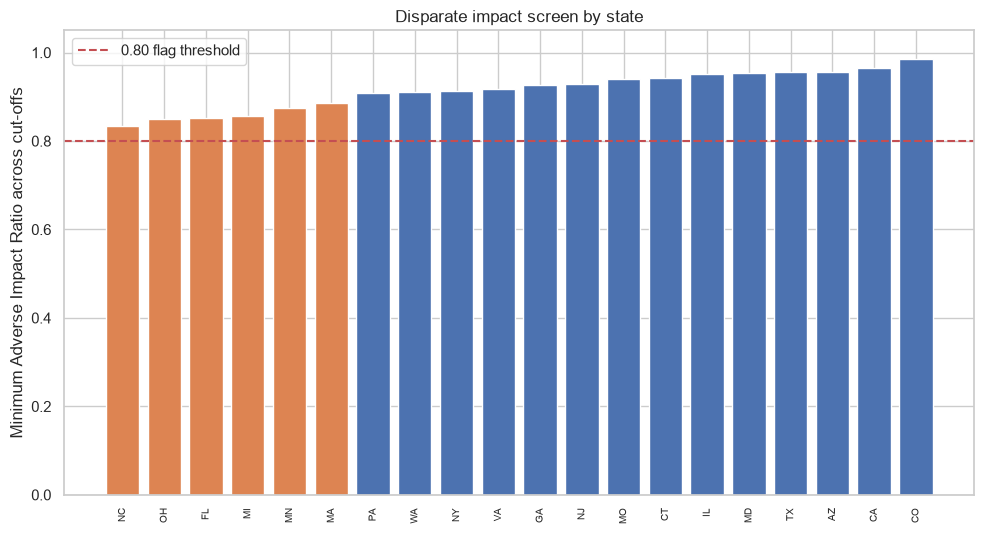

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
order = state_air.groupby("group").AIR.min().sort_values()
colors = ["#C44E52" if v < 0.80 else "#DD8452" if v < 0.90 else "#4C72B0" for v in order]
ax.bar(range(len(order)), order.values, color=colors)
ax.axhline(0.80, color="#C44E52", linestyle="--", lw=1.5, label="0.80 flag threshold")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order.index, rotation=90, fontsize=7)
ax.set_ylabel("Minimum Adverse Impact Ratio across cut-offs")
ax.set_title("Disparate impact screen by state")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "07_adverse_impact.png", dpi=140)
plt.show()

## 11.4 Does the model actually use geography?

AIR measures outcomes. A separate question is whether the model *relies* on
location, because a model that ignores geography cannot redline through it
directly — though it can still do so through correlated variables.

The cleanest test is counterfactual: hold every other characteristic fixed,
change only the state, and see how much the score moves.

In [7]:
sample = test.sample(n=3000, random_state=RANDOM_STATE)
CENSUS_REGION = {
    "NORTHEAST": ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"],
    "MIDWEST": ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"],
    "SOUTH": ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV", "AL", "KY",
              "MS", "TN", "AR", "LA", "OK", "TX"],
    "WEST": ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"],
}

cf = {}
for region in CENSUS_REGION:
    s = sample.copy()
    s["region"] = region
    Xs = s[cfg["TREE_NUM"] + cfg["TREE_CAT"]].copy()
    for c in cfg["TREE_CAT"]:
        Xs[c] = pd.Categorical(Xs[c], categories=cfg["tree_categories"][c])
    p = lgbm.predict_proba(Xs)[:, 1]
    cf[region] = np.clip(cfg["OFFSET"] + cfg["FACTOR"] * np.log((1 - p) / p), 300, 850)

cf_df = pd.DataFrame(cf)
swing = (cf_df.max(axis=1) - cf_df.min(axis=1))
print("Counterfactual: the same 3,000 applicants, region reassigned\n")
print(cf_df.mean().round(2).to_frame("mean score").to_string())
print(f"\nPer-applicant score swing from region alone:")
print(f"  mean {swing.mean():.2f} points, median {swing.median():.2f}, max {swing.max():.2f}")
print(f"\nFor scale, the full score range in use is about 140 points.")

Counterfactual: the same 3,000 applicants, region reassigned

           mean score
NORTHEAST      533.21
MIDWEST        534.70
SOUTH          534.48
WEST           536.55

Per-applicant score swing from region alone:
  mean 4.24 points, median 3.43, max 14.77

For scale, the full score range in use is about 140 points.


**Reassigning an applicant's region moves their score by 4.2 points on
average** (median 3.4), against a working range of roughly 140 points. So
geography carries about 3% of the score — small, and consistent with Phase 4,
where `region` had an Information Value of 0.0008, the weakest characteristic
in the set.

But the **maximum swing is 14.8 points**, so for some applicants geography is
worth over 10% of the range. The average understates the tail, and in a real
review the tail is what gets examined: the question is not "how much does
location matter on average" but "who does it matter most for, and why".

This addresses direct use of geography only. It does **not** clear the model
of proxy discrimination through correlated variables, which is the harder
problem and the subject of the next section.

## 11.5 Which characteristics could carry a protected attribute?

Proxy discrimination does not need geography. Any characteristic correlated
with a protected class can carry it. The honest audit is to name them.

In [8]:
proxy_notes = pd.DataFrame([
    {"characteristic": "annual_inc / log_annual_inc",
     "concern": "Income correlates strongly with race and sex in the US. The single "
                "largest proxy risk in this model.",
     "defensible?": "Yes - ability to repay is the core business justification"},
    {"characteristic": "addr_state / region",
     "concern": "Residential segregation makes location a race proxy. The redlining "
                "mechanism.",
     "defensible?": "Weakly - and the model barely uses it (see 11.4)"},
    {"characteristic": "emp_length / emp_length_missing",
     "concern": "Employment stability correlates with age, and with caregiving "
                "interruptions that fall disproportionately on women.",
     "defensible?": "Partly - relevant, but age is a prohibited basis"},
    {"characteristic": "home_ownership",
     "concern": "US homeownership rates differ sharply by race.",
     "defensible?": "Weakly - correlated with wealth more than with repayment"},
    {"characteristic": "longest_credit_length",
     "concern": "Directly proportional to age, and thin-file borrowers skew young "
                "and minority.",
     "defensible?": "Contested - age is explicitly prohibited under ECOA"},
])
proxy_notes

,characteristic,concern,defensible?
0,annual_inc / log_annual_inc,Income correlates strongly with race and sex i...,Yes - ability to repay is the core business ju...
1,addr_state / region,Residential segregation makes location a race ...,Weakly - and the model barely uses it (see 11.4)
2,emp_length / emp_length_missing,"Employment stability correlates with age, and ...","Partly - relevant, but age is a prohibited basis"
3,home_ownership,US homeownership rates differ sharply by race.,Weakly - correlated with wealth more than with...
4,longest_credit_length,"Directly proportional to age, and thin-file bo...",Contested - age is explicitly prohibited under...


`longest_credit_length` is the one a compliance function would question hardest.
It is close to a linear function of age, and age is an explicitly prohibited
basis. It is a legitimate risk characteristic *and* an age proxy at the same
time, and resolving that tension is a legal judgement rather than a modelling
one — which is precisely why fair lending review sits outside the modelling
team.

## 11.6 What this analysis cannot establish

Stating the limits is part of the deliverable. An analysis that overclaims is
worse than none, because it manufactures false assurance.

**No protected attribute is observed.** Everything here works through
geography, a weak proxy. A real review would use **BISG** (Bayesian Improved
Surname Geocoding), the CFPB's own method, which combines surname and
census-tract demographics to estimate race probabilistically. That needs
surnames and tract-level addresses, neither of which this dataset has.

**State is too coarse.** Redlining operates at neighbourhood level. Census
tract or ZIP would be the right granularity; state averages wash out exactly
the disparities that matter.

**Only the approve/decline decision is tested.** Real reviews also cover
pricing, credit limits, and marketing reach.

**Passing the four-fifths rule is not a clean bill of health.** It is a
screening threshold. A model can clear it and still produce a less
discriminatory alternative on closer analysis, and that alternative is what
regulators expect a lender to have searched for.

## Phase 11 summary

**The model passes the standard disparate impact screen on geography.** No
census region falls below an AIR of 0.80 at any cut-off between the 10th and
50th score percentiles.

**Geography carries about 3% of the score.** Reassigning an applicant's
region moves it by 4.2 points on average against a ~140-point working range,
consistent with `region` having the lowest Information Value of any
characteristic. The maximum swing is 14.8 points, so the average understates
a tail that a real review would examine.

**The real proxy risk is income and credit history length, not location.**
`longest_credit_length` is close to a linear function of age, and age is a
prohibited basis under ECOA — a tension that is a legal judgement, not a
modelling one.

**The analysis is a screen, not a clearance.** Without surnames or tract-level
geography, BISG is impossible, and BISG is what an actual review would run.
Documenting that gap is the correct outcome here: the value of this notebook
is in having looked and having been precise about what looking could and could
not show.